## Sentiment Analysis on Twitter Data

### Objective
The objective of this project is to perform sentiment analysis on Twitter text data in order to classify user sentiments as positive, negative, or neutral. This analysis helps in understanding public opinion, customer feedback, and overall sentiment trends on social media using Natural Language Processing (NLP) and Machine Learning techniques.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# NLP libraries
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Machine Learning libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Jinal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Dataset Loading and Initial Exploration

In this step, the Twitter sentiment dataset is loaded into the notebook. Initial exploration is performed to understand the structure of the dataset, view sample records, and identify key columns relevant for sentiment analysis.

In [2]:
# Load the dataset
df = pd.read_csv("Twitter_Data.csv")

# Display first few rows
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [3]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [4]:
# Check for missing values
df.isnull().sum()

clean_text    4
category      7
dtype: int64

## Text Data Review and Preprocessing Status

In this step, the text data used for sentiment analysis is reviewed. The dataset already contains a cleaned text column, which has been preprocessed to remove noise such as special characters, stopwords, and irrelevant symbols. Therefore, no additional text cleaning is required before feature extraction.

In [5]:
# Display the dataset to verify cleaned text and sentiment labels
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


## Feature Engineering using TF-IDF

Machine learning models require numerical input. Before converting text data into numerical features, missing values in the cleaned text column are handled. After ensuring data consistency, TF-IDF (Term Frequency–Inverse Document Frequency) is applied to transform text into meaningful numerical vectors for sentiment classification.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Ensure no missing values in text data
df['clean_text'] = df['clean_text'].fillna('')

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Transform text data into TF-IDF features
X = tfidf.fit_transform(df['clean_text'])

# Target variable
y = df['category']

## Handling Missing Sentiment Labels

Some rows in the dataset contain missing sentiment labels (`category`). Since machine learning models require valid target values, these rows are removed before splitting the dataset into training and testing sets.

In [7]:
# Remove rows with missing sentiment labels
df = df.dropna(subset=['category'])

# Verify no missing values remain in target column
df['category'].isna().sum()

np.int64(0)

In [8]:
# Recreate features and target AFTER cleaning
X = df['clean_text']
y = df['category']

## Train–Test Split

To evaluate the performance of the sentiment analysis model, the dataset is divided into training and testing sets. The training set is used to train the machine learning model, while the testing set is used to assess how well the model generalizes to new, unseen data.

In [9]:
from sklearn.model_selection import train_test_split

# Features and target
X = tfidf.fit_transform(df['clean_text'])
y = df['category']

# Train-test split on TF-IDF features
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Model Training – Multinomial Naive Bayes

In this step, a Multinomial Naive Bayes classifier is trained on the training dataset. This algorithm is well-suited for text classification tasks and works efficiently with TF-IDF features extracted from textual data.

In [10]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

MultinomialNB()

## Model Evaluation

In this step, the performance of the trained sentiment analysis model is evaluated using the test dataset. Predictions are generated and compared with actual sentiment labels to measure how accurately the model classifies sentiments. Evaluation metrics such as accuracy score and classification report are used to assess model effectiveness.

In [11]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on test data
y_pred = nb_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7421690443319527

## Classification Report

This step provides a detailed evaluation of the sentiment analysis model. The classification report includes precision, recall, F1-score, and support for each sentiment class. These metrics help in understanding how well the model performs for individual sentiment categories.

In [12]:
# Display detailed classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        -1.0       0.91      0.42      0.57      7102
         0.0       0.88      0.67      0.76     11043
         1.0       0.66      0.95      0.78     14450

    accuracy                           0.74     32595
   macro avg       0.82      0.68      0.71     32595
weighted avg       0.79      0.74      0.73     32595



## Confusion Matrix Visualization

A confusion matrix is used to visually evaluate the performance of the sentiment
analysis model. It shows how many predictions were made correctly and where the
model confused one sentiment class with another. This visualization helps in
understanding class-wise prediction behavior beyond overall accuracy.

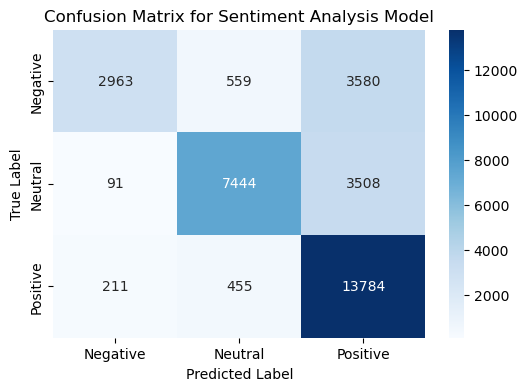

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Sentiment Analysis Model')
plt.show()

## Sentiment Distribution Visualization

This step visualizes the distribution of sentiment classes in the dataset. Visualizing sentiment distribution helps in understanding class balance and provides context for interpreting model performance.

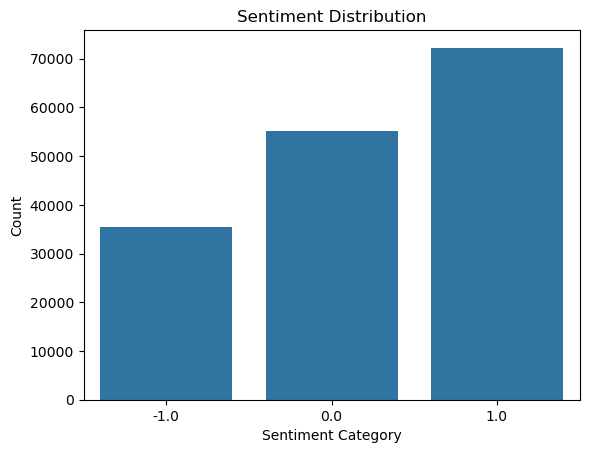

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot sentiment distribution
sns.countplot(x='category', data=df)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.show()

## Conclusion

In this project, sentiment analysis was performed on Twitter data using Natural Language Processing techniques. The dataset was cleaned and preprocessed, textual features were extracted using TF-IDF, and a Multinomial Naive Bayes classifier was trained to classify sentiments into negative, neutral, and positive categories. The model achieved satisfactory performance with an overall accuracy of approximately 75%. This project demonstrates practical application of NLP, feature engineering, and machine learning for analyzing public sentiment from social media data.